# Phân tích Học máy và Dự báo Tài chính - 4 Ngân hàng Trọng tâm (BIDV, TCB, VCB, CTG)

Notebook này thực hiện luồng phân tích học máy hoàn chỉnh cho báo cáo khoa học và đánh giá của bốn ngân hàng trọng điểm của dự án bao gồm:
1. **BIDV (BID)**
2. **Techcombank (TCB)**
3. **Vietcombank (VCB)**
4. **VietinBank (CTG)**

Nội dung bao gồm ba phần mô hình chính:
* **K-Means + PCA**: Phân cụm nhóm chiến lược và sức khỏe ngân hàng.
* **Random Forest**: Phân loại và cảnh báo sớm rủi ro nợ xấu tín dụng (NPL >= 3%).
* **LSTM (Deep Learning)**: Dự báo giá cổ phiếu ngắn hạn từ T+1 đến T+5 cho cả 4 ngân hàng.

## 1. Thiết lập Môi trường và Thư viện

In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, recall_score, roc_auc_score, roc_curve, f1_score, mean_squared_error
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# Thiết lập thư mục gốc của dự án (notebook nằm trong thư mục notebooks/ nên gốc là ..)
BASE_DIR = os.path.abspath("..")
INPUT_DIR = os.path.join(BASE_DIR, "data", "data_ml", "input")
PROCESSED_DIR = os.path.join(BASE_DIR, "data", "processed")

print("TensorFlow Version:", tf.__version__)
print("Môi trường đã được cấu hình thành công.")

TensorFlow Version: 2.20.0
Môi trường đã được cấu hình thành công.


## 2. Phân cụm Ngân hàng (PCA + K-Means)

Chúng ta tiến hành phân cụm trên toàn bộ 46 ngân hàng thương mại Việt Nam bằng 11 chỉ số tài chính CAMELS, sau đó định vị xem 4 ngân hàng trọng tâm nằm ở cụm nào.

In [2]:
# Tải dữ liệu CAMELS của 46 ngân hàng
banks_camels_path = os.path.join(INPUT_DIR, "banks_camels_46.csv")
df_camels = pd.read_csv(banks_camels_path)

# Lấy năm dữ liệu mới nhất có sẵn cho mỗi ngân hàng (năm 2022)
df_latest_bank = df_camels.sort_values("date_key").groupby("bank_code").last().reset_index()

camels_features = ['npl_ratio', 'llp_ratio', 'roa', 'roe', 'nim', 'cir', 'eta', 'etd', 'lta', 'ltd', 'gta']

# Chuẩn hóa dữ liệu
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_latest_bank[camels_features])

# Giảm chiều PCA xuống 4 thành phần để giải thích >80% phương sai
pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)
print(f"PCA: 4 thành phần chính giải thích được {sum(pca.explained_variance_ratio_)*100:.2f}% phương sai.")

# Huấn luyện K-Means (K=2)
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_pca)
df_latest_bank["cluster"] = clusters

# Hiển thị vị trí phân cụm của 4 ngân hàng trọng tâm (chú ý: BID trong file CAMELS được ký hiệu là BIDV)
focus_tickers = ["BIDV", "TCB", "VCB", "CTG"]
print("\nVị trí phân cụm của 4 Ngân hàng Trọng tâm:")
display(df_latest_bank[df_latest_bank["bank_code"].isin(focus_tickers)][["bank_code", "bank_name", "cluster", "npl_ratio", "roa", "roe", "nim"]])

PCA: 4 thành phần chính giải thích được 82.67% phương sai.



Vị trí phân cụm của 4 Ngân hàng Trọng tâm:


,bank_code,bank_name,cluster,npl_ratio,roa,roe,nim
4,BIDV,Joint Stock Commercial Bank for Investment and...,0,0.011875,0.008686,0.176793,0.089557
7,CTG,Vietnam Joint Stock Commercial Bank of Industr...,0,0.012395,0.007589,0.126873,0.095937
35,TCB,Viet Nam Technological and Commercial Joint St...,0,0.007211,0.031774,0.180176,0.141379
40,VCB,Joint Stock Commercial Bank for Foreign Trade ...,0,0.006830,0.024897,0.337459,0.077671


### Trực quan hóa Phân cụm và Định vị các Ngân hàng Trọng tâm

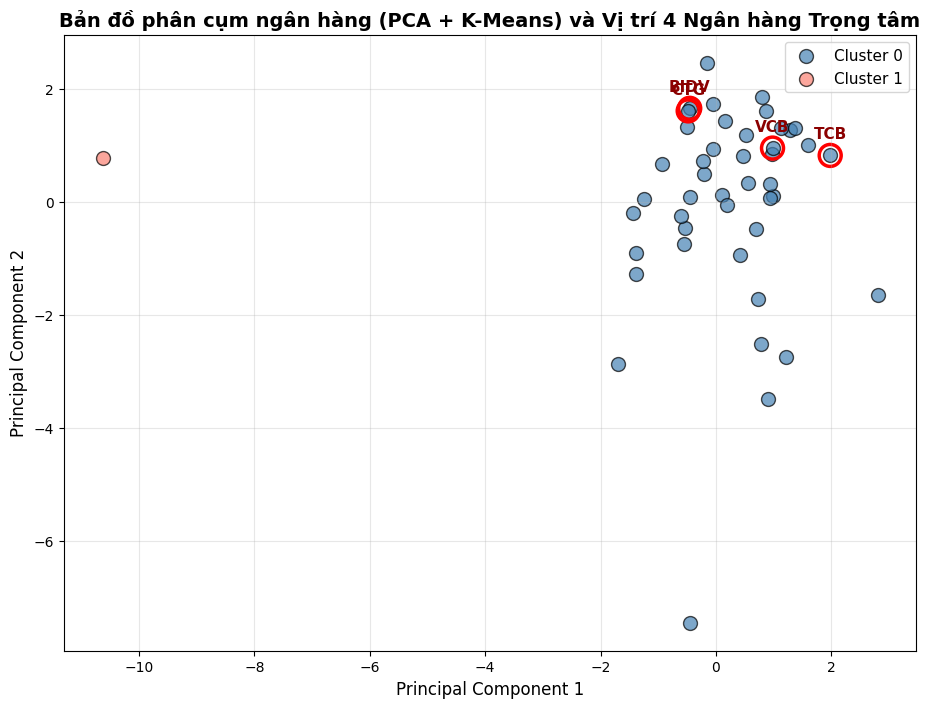

In [3]:
plt.figure(figsize=(11, 8))
colors = ['steelblue', 'salmon']
for c in range(2):
    plt.scatter(X_pca[df_latest_bank["cluster"] == c, 0], 
                X_pca[df_latest_bank["cluster"] == c, 1], 
                label=f"Cluster {c}", c=colors[c], s=100, alpha=0.7, edgecolors='k')

# Vẽ vòng tròn đỏ và chú thích cho 4 ngân hàng trọng tâm
for idx, row in df_latest_bank.iterrows():
    if row["bank_code"] in focus_tickers:
        plt.scatter(X_pca[idx, 0], X_pca[idx, 1], s=250, facecolors='none', edgecolors='red', linewidths=2.5)
        plt.annotate(row["bank_code"], (X_pca[idx, 0], X_pca[idx, 1]), 
                     textcoords="offset points", xytext=(0,12), ha='center', fontweight='bold', color='darkred', fontsize=11)

plt.xlabel("Principal Component 1", fontsize=12)
plt.ylabel("Principal Component 2", fontsize=12)
plt.title("Bản đồ phân cụm ngân hàng (PCA + K-Means) và Vị trí 4 Ngân hàng Trọng tâm", fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

## 3. Phân loại Rủi ro Tín dụng (Random Forest)

Huấn luyện mô hình phân loại nhị phân cảnh báo sớm xem ngân hàng có rơi vào trạng thái nợ xấu cao (NPL >= 3%) hay không.

In [4]:
# Tạo nhãn rủi ro (risk_label = 1 nếu npl_ratio >= 0.03)
df_rf = df_camels.copy()
df_rf["risk_label"] = (df_rf["npl_ratio" ] >= 0.03).astype(int)

# Gom các cột đặc trưng mô hình
rf_features = camels_features + ["total_assets", "total_deposits", "total_loans", "total_equity"]
rf_features = [c for c in rf_features if c != "npl_ratio" and c in df_rf.columns]

df_rf_clean = df_rf.dropna(subset=rf_features + ["risk_label"]).sort_values("date_key").reset_index(drop=True)

# Chia tập dữ liệu Train/Test theo thời gian (80/20)
split_idx = int(len(df_rf_clean) * 0.8)
X_train = df_rf_clean.iloc[:split_idx][rf_features]
X_test = df_rf_clean.iloc[split_idx:][rf_features]
y_train = df_rf_clean.iloc[:split_idx]["risk_label"]
y_test = df_rf_clean.iloc[split_idx:]["risk_label"]

# Huấn luyện Random Forest
rf = RandomForestClassifier(n_estimators=200, max_depth=10, class_weight="balanced", random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Đánh giá mô hình
y_pred = rf.predict(X_test)
y_prob = rf.predict_proba(X_test)[:, 1]

print("=== KẾT QUẢ ĐÁNH GIÁ RANDOM FOREST ===")
print(f"AUC-ROC Score: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Recall (High Risk class): {recall_score(y_test, y_pred, pos_label=1):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

=== KẾT QUẢ ĐÁNH GIÁ RANDOM FOREST ===
AUC-ROC Score: 0.9538
Recall (High Risk class): 0.1429

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.99      0.95       119
           1       0.67      0.14      0.24        14

    accuracy                           0.90       133
   macro avg       0.79      0.57      0.59       133
weighted avg       0.88      0.90      0.87       133



### Dự báo Xác suất Rủi ro Nợ xấu đối với 4 Ngân hàng Trọng tâm trong Tập Kiểm thử

In [5]:
# Trích xuất các dòng dự báo thuộc về 4 ngân hàng trọng tâm từ tập kiểm thử
test_output = df_rf_clean.iloc[split_idx:].copy()
test_output["predicted_risk_label"] = y_pred
test_output["risk_probability"] = y_prob

focus_preds = test_output[test_output["bank_code"].isin(focus_tickers)].sort_values(["bank_code", "date_key"])
print("Dự báo rủi ro nợ xấu cho các Ngân hàng Trọng tâm trong tập kiểm thử (2020-2022):")
display(focus_preds[["date_key", "bank_code", "npl_ratio", "risk_label", "predicted_risk_label", "risk_probability"]])

Dự báo rủi ro nợ xấu cho các Ngân hàng Trọng tâm trong tập kiểm thử (2020-2022):


,date_key,bank_code,npl_ratio,risk_label,predicted_risk_label,risk_probability
546,20191231,BIDV,0.017454,0,0,0.005000
597,20201231,BIDV,0.017598,0,0,0.080000
624,20211231,BIDV,0.010067,0,0,0.045000
643,20221231,BIDV,0.011875,0,0,0.030000
530,20181231,CTG,0.015850,0,0,0.034384
570,20191231,CTG,0.011562,0,0,0.030000
588,20201231,CTG,0.009452,0,0,0.025000
617,20211231,CTG,0.012648,0,0,0.040000
634,20221231,CTG,0.012395,0,0,0.025000
533,20181231,TCB,0.017528,0,0,0.080000


## 4. Dự báo Giá Cổ phiếu ngắn hạn (LSTM Deep Learning)

Chúng ta tiến hành huấn luyện các mô hình mạng nơ-ron hồi quy LSTM riêng biệt cho từng ngân hàng trong 4 ngân hàng trọng tâm để dự báo xu hướng giá đóng cửa 5 phiên tiếp theo (T+1 đến T+5).

In [6]:
def load_and_prep_stock(symbol):
    """Tải dữ liệu lịch sử giá, tính toán các biến đặc trưng mới."""
    csv_path = os.path.join(PROCESSED_DIR, symbol.lower(), f"{symbol.lower()}_stock_history.csv")
    df = pd.read_csv(csv_path)
    df["time"] = pd.to_datetime(df["time"])
    df = df.sort_values("time").reset_index(drop=True)
    
    # Tính toán đặc trưng phục vụ LSTM
    df["open_price"] = df["open"]
    df["high_price"] = df["high"]
    df["low_price"] = df["low"]
    df["close_price"] = df["close"]
    df["trading_volume"] = df["volume"]
    df["price_change_pct"] = df["close_price"].pct_change().replace([np.inf, -np.inf], 0).fillna(0)
    df["volume_change_pct"] = df["trading_volume"].pct_change().replace([np.inf, -np.inf], 0).fillna(0)
    
    # Đảm bảo không còn giá trị NaN hoặc vô cùng trước khi đưa vào mô hình
    for col in ["price_change_pct", "volume_change_pct"]:
        df[col] = df[col].replace([np.inf, -np.inf], 0).fillna(0)
        
    return df

def create_sequences(data, window, horizon):
    """Tạo chuỗi trượt (sliding windows)."""
    X, y = [], []
    for i in range(len(data) - window - horizon + 1):
        X.append(data[i : i + window, :])
        y.append(data[i + window : i + window + horizon, 0]) # Cột 0 là close_price
    return np.array(X), np.array(y)

window_size = 5
forecast_horizon = 5
feature_cols = ["close_price", "open_price", "high_price", "low_price", "trading_volume", "price_change_pct", "volume_change_pct"]

def train_lstm_for_bank(symbol):
    """Huấn luyện mạng LSTM cho từng mã chứng khoán."""
    df = load_and_prep_stock(symbol)
    data_values = df[feature_cols].values
    
    # Thay thế triệt để inf/NaN
    data_values = np.nan_to_num(data_values, nan=0.0, posinf=0.0, neginf=0.0)
    
    # Chuẩn hóa dữ liệu về khoảng [0, 1]
    scaler = MinMaxScaler()
    scaled_data = scaler.fit_transform(data_values)
    
    # Chia tập Train/Test theo tỷ lệ 80/20
    split_idx = int(len(scaled_data) * 0.8)
    train_data = scaled_data[:split_idx]
    test_data = scaled_data[split_idx:]
    
    X_train, y_train = create_sequences(train_data, window_size, forecast_horizon)
    X_test, y_test = create_sequences(test_data, window_size, forecast_horizon)
    
    # Khởi tạo mô hình mạng LSTM
    model = Sequential([
        LSTM(64, input_shape=(window_size, len(feature_cols)), return_sequences=False),
        Dropout(0.2),
        Dense(32, activation='relu'),
        Dense(forecast_horizon)
    ])
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    # Huấn luyện mô hình (chạy ẩn verbose=0 để tránh tràn log)
    model.fit(X_train, y_train, epochs=40, batch_size=16, validation_split=0.1, verbose=0)
    
    # Dự báo trên tập kiểm thử
    y_pred_scaled = model.predict(X_test, verbose=0)
    
    # Đổi ngược về khoảng giá trị thực tế
    dummy_pred = np.zeros((len(y_pred_scaled), len(feature_cols)))
    dummy_test = np.zeros((len(y_test), len(feature_cols)))
    
    actual_preds = []
    actual_targets = []
    
    for h in range(forecast_horizon):
        dummy_pred[:, 0] = y_pred_scaled[:, h]
        inv_pred = scaler.inverse_transform(dummy_pred)[:, 0]
        actual_preds.append(inv_pred)
        
        dummy_test[:, 0] = y_test[:, h]
        inv_test = scaler.inverse_transform(dummy_test)[:, 0]
        actual_targets.append(inv_test)
        
    actual_preds = np.array(actual_preds).T
    actual_targets = np.array(actual_targets).T
    
    rmse = np.sqrt(mean_squared_error(actual_targets, actual_preds))
    print(f"[{symbol}] LSTM Test RMSE: {rmse:.4f}")
    
    # Dự đoán giá đóng cửa 5 ngày tiếp theo sau ngày cuối cùng của tập dữ liệu
    last_window_scaled = scaled_data[-window_size:]
    last_window_scaled = np.expand_dims(last_window_scaled, axis=0)
    next_5_scaled = model.predict(last_window_scaled, verbose=0)[0]
    
    dummy_next = np.zeros((forecast_horizon, len(feature_cols)))
    dummy_next[:, 0] = next_5_scaled
    next_5_prices = scaler.inverse_transform(dummy_next)[:, 0]
    
    return next_5_prices, actual_preds, actual_targets, df

# Chạy huấn luyện và dự báo cho từng mã ngân hàng
symbols = ["BID", "TCB", "VCB", "CTG"]
lstm_results = {}
for s in symbols:
    print(f"Đang chạy mô hình LSTM cho mã: {s}...")
    next_5, preds, targets, df = train_lstm_for_bank(s)
    lstm_results[s] = {
        "next_5": next_5,
        "preds": preds,
        "targets": targets,
        "df": df
    }

Đang chạy mô hình LSTM cho mã: BID...


C:\Users\QUOC ANH\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[BID] LSTM Test RMSE: 2.3582
Đang chạy mô hình LSTM cho mã: TCB...


C:\Users\QUOC ANH\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[TCB] LSTM Test RMSE: 1.8450
Đang chạy mô hình LSTM cho mã: VCB...


C:\Users\QUOC ANH\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[VCB] LSTM Test RMSE: 6.4479
Đang chạy mô hình LSTM cho mã: CTG...


C:\Users\QUOC ANH\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


[CTG] LSTM Test RMSE: 1.8848


### Trực quan hóa Kết quả Dự báo Giá Cổ phiếu 5 phiên tiếp theo (T+1 đến T+5)

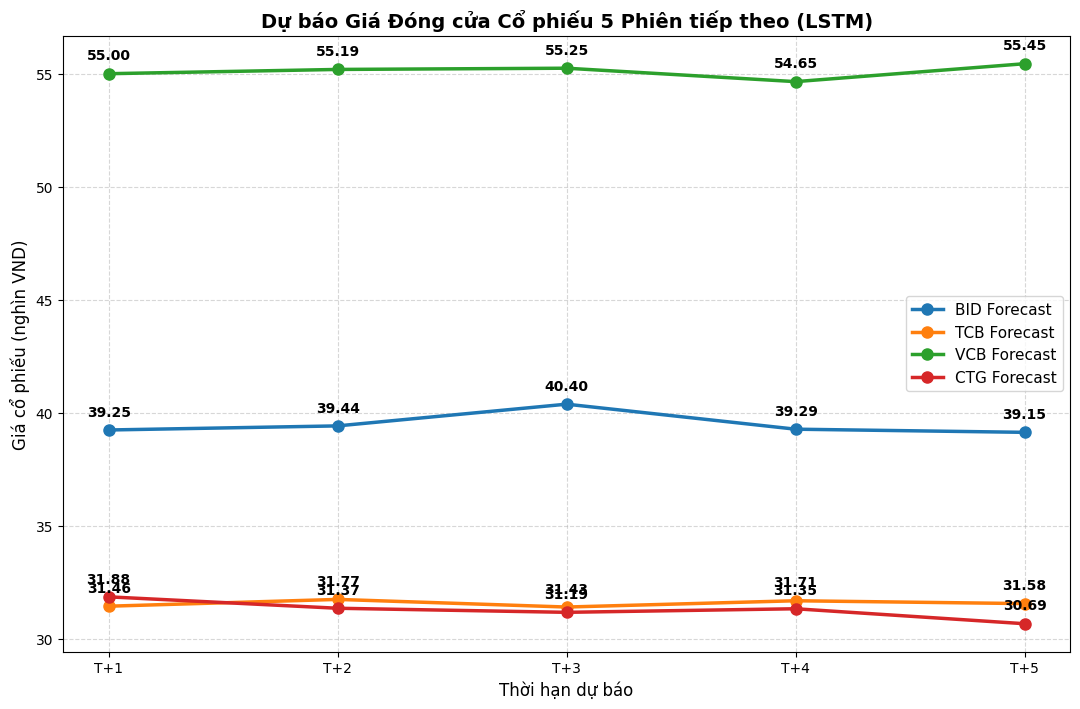

In [7]:
plt.figure(figsize=(13, 8))
horizons = [f"T+{i+1}" for i in range(5)]

for s in symbols:
    prices = lstm_results[s]["next_5"]
    plt.plot(horizons, prices, marker='o', markersize=8, linewidth=2.5, label=f"{s} Forecast")
    for i, p in enumerate(prices):
        plt.annotate(f"{p:.2f}", (horizons[i], p), textcoords="offset points", xytext=(0,10), ha='center', fontweight='semibold')

plt.title("Dự báo Giá Đóng cửa Cổ phiếu 5 Phiên tiếp theo (LSTM)", fontsize=14, fontweight='bold')
plt.xlabel("Thời hạn dự báo", fontsize=12)
plt.ylabel("Giá cổ phiếu (nghìn VND)", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(fontsize=11)
plt.show()